In [6]:
# Needed for UPM virtual desktop and package ore_algebra.
# To be executed once.
%pip install --no-build-isolation -e ..

Obtaining file:///home/upm/dalgebra_ore
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Cloning https://github.com/mkauers/ore_algebra.git to /tmp/pip-install-4odps7jf/ore-algebra_fb15f751175c4364b58de597baf02700
  Running command git clone --filter=blob:none --quiet https://github.com/mkauers/ore_algebra.git /tmp/pip-install-4odps7jf/ore-algebra_fb15f751175c4364b58de597baf02700
  Resolved https://github.com/mkauers/ore_algebra.git to commit d234e3d8ae1d451e734218b02aa5f05a3ffda2d9
  Preparing metadata (pyproject.toml) ... done
  Building editable for dalgebra (pyproject.toml) ... done
  Created wheel for dalgebra: filename=dalgebra-0.0.8-0.editable-py3-none-any.whl size=16840 sha256=c437232a3a6f7b9f34413f056f985af3de440f0bd883e7b7e88688e4cec28b93
  Stored in directory: /tmp/pip-ephem-wheel-cache-m_sxd96h/wheels/4e/06/f5/ce8ee18b65487b782db89b6a5b2ad3da22d35fd7bd893761b1
  Created wheel for ore_algebra: filename=ore

In [1]:
import sys
sys.path.insert(0,"..") # dalgebra is here
from dalgebra import *

# 1. Skew as Differential

In [2]:
# Diff simple example.
B = DifferentialRing(QQ[x], diff)
x = B(x)
S.<z> = DPolynomialRing(B)
P = z[2] - 3*x*z[1] + (x^2 - 1)*z[0]
Q = z[3] - z[0]
P.sylvester_resultant(Q)

# Skew parading as diff.
R.<t> = QQ[]
s = R.Hom(R)([0])
td = R.derivation_module()(t)
tR = DRing(R, td, types=["skew"])
print(tR) # Not a diff per se.
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)


# Analogous to P,Q
p = y[2]-3*t*y[1] + (t^2-1)*y[0]
q = y[3] - y[0]

# __eq__ already checks coeffs, then goes for difference.
# Between different rings difference does not work, so let's patch it for these tests.

def eq_coeff(a:DPolynomial,b:DPolynomial):
    try:
        return a==b
    except:
        return False

Ring [[Univariate Polynomial Ring in t over Rational Field], (d/dt,)]


In [3]:
# A bunch of tests. First are mine, then I used Gemini for inspiration.

assert eq_coeff(S(1),O(1))
assert not eq_coeff(S(1),O(0))

assert eq_coeff(y[0],z[0])
assert eq_coeff(x,t)

assert eq_coeff(p,P)
assert eq_coeff(q,Q)

# Let's check it's not always True.
assert not eq_coeff(p+1,P)
assert not eq_coeff(q,2*Q)

assert eq_coeff(p.sylvester_resultant(q),P.sylvester_resultant(Q)) 
assert eq_coeff(p.gcd(q),P.gcd(Q))

# Let's even flip to check it works fine
assert eq_coeff(p.sylvester_resultant(q),Q.sylvester_resultant(P)) 
assert eq_coeff(p.gcd(q),Q.gcd(P))

assert O(0).is_zero()
assert (p-p).is_zero()

# Gemini's proposal
# 1. Arithmetic
assert eq_coeff(p * q, P * Q)
assert eq_coeff(p**2, P**2)

# 2. Division (using polynomials that cleanly divide)
p_mult = p * q
P_mult = P * Q
assert eq_coeff(p_mult // q, P_mult // Q)
assert eq_coeff(p_mult % q, P_mult % Q)

# 3. Composition (Operational Product)
assert eq_coeff(p.dot(q, y), P.dot(Q, z))

# 4. Lie Bracket (Commutator)
assert eq_coeff(p.lie_bracket(q, y), P.lie_bracket(Q, z))

# 5. Symmetric Power
assert eq_coeff(p.sym_power(2, y), P.sym_power(2, z))

# 6. Differential Rankings
# Skew implementation needs to be reviewed deeper.
assert eq_coeff(p.leader(), P.leader())
assert eq_coeff(q.leader(), Q.leader())

assert eq_coeff(p.initial(), P.initial())
assert eq_coeff(p.separant(), P.separant())

# 7. Coefficient and Degree Extractors
assert p.degree() == P.degree()
assert p.order(y) == P.order(z)
assert p.lorder(y) == P.lorder(z)

assert eq_coeff(p.constant_coefficient(), P.constant_coefficient())
assert eq_coeff(p.coefficient_without_var(y[0]), P.coefficient_without_var(z[0]))

# 8. Direct Application of the Operator
assert eq_coeff(p.operation(), P.operation())
assert eq_coeff(q.operation(times=2), Q.operation(times=2))

# 9. Solving (requires setting up a specific integrable polynomial)
# Standard Diff
#P_solve = z[1] 
#P_sol = P_solve.solve(z)

# Skew as Diff
#p_solve = y[1]
#p_sol = p_solve.solve(y)
# __inverse_skew not implemented.
#assert eq_coeff(p_sol, P_sol)

# 10. Power Series Initial Conditions
# P_series does not work. Maybe some other version or Gemini's hallucination.

#initials = {0: 1} # z_0 = 1, y_0 = 1
#P_series = P_solve.power_series_solution(z, initials)
#p_series = p_solve.power_series_solution(y, initials)

# Series objects might not support direct equality with eq_coeff, 
# so you may need to compare their truncated polynomial forms or string representations.
#assert str(P_series) == str(p_series)

# 11. Linearity checks
assert p.is_linear([y]) == P.is_linear([z])
assert not (y[0]*y[1]).is_linear([y]) 

# 12. Operator Cast and Application
# Take a linear polynomial, cast it to an operator, and apply it to a base element
#p_lin = t * y[1] + y[0]
#P_lin = x * z[1] + z[0]

# "Method needs a revision", ok.
#p_op = p_lin.as_linear_operator()
#P_op = P_lin.as_linear_operator()

# Apply the operators to an element in the base ring (e.g., t^2 and x^2)
#assert eq_coeff(p_op(t^2), P_op(x^2))

# 13. Direct variable substitution
# Evaluating the 0-th order and 1-st order variables at specific integers/elements
dict_P = {str(z[0]): 2, str(z[1]): x}
dict_p = {str(y[0]): 2, str(y[1]): t}

assert eq_coeff(p.eval(dic=dict_p), P.eval(dic=dict_P))

# 14. Evaluating purely coefficients (inner_kwds execution path)
assert eq_coeff(p.eval(t=5), P.eval(x=5))

# 15. Fraction Field Coercion
# I'm getting some interesting errors. It lacks twist, but 
# it is also applying it to DPolynomials which would be strange.
#P_frac = P / (z[0] + 1)
#p_frac = p / (y[0] + 1)

#assert eq_coeff(p_frac.numerator(), P_frac.numerator())
#assert eq_coeff(p_frac.denominator(), P_frac.denominator())

# 16. Content and Common terms (Algebraic extraction)
assert eq_coeff(p.content(), P.content())
assert eq_coeff(p.common_term(), P.common_term())

# 2. Skew as difference

In [4]:
# Skew parading as difference.
R.<t> = QQ[]
s = R.Hom(R)([t+1])
td = R.derivation_module(twist=s)(0)
tR = DRing(R, td, types=["skew"])
print(tR) # Not a diff per se.
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)
# Looks good.
print(((t+1)*y[0]).operation())
print((y[2]).dot(t*y[1],y))
p = y[2] - 3*t*y[1] + (t^2-1)*y[0]
q = y[3] - y[0]
print(O.sylvester_subresultant(p, q, k=1, i=0))
print(O.sylvester_subresultant(p, q, k=1, i=1))


# Honest to God difference.
B = DifferenceRing(QQ[x], QQ[x].Hom(QQ[x])(x+1)); x = B(x)
S.<z> = DPolynomialRing(B)
P = z[2] - 3*x*z[1] + (x^2 - 1)*z[0]
Q = z[3] - z[0]
print(S.sylvester_subresultant(P, Q, k=1, i=0))
print(S.sylvester_subresultant(P, Q, k=1, i=1))

Ring [[Univariate Polynomial Ring in t over Rational Field], (0,)]
(t + 2)*y_1
(t + 2)*y_3
-(3*t^3 + 3*t^2 - 3*t - 2)
(8*t^2 + 7*t)
-(3*x^3 + 3*x^2 - 3*x - 2)
(8*x^2 + 7*x)


In [5]:
# A bunch of tests. First are mine, then I used Gemini for inspiration.

assert eq_coeff(S(1),O(1))
assert not eq_coeff(S(1),O(0))

assert eq_coeff(y[0],z[0])
assert eq_coeff(x,t)

assert eq_coeff(p,P)
assert eq_coeff(q,Q)

# Let's check it's not always True.
assert not eq_coeff(p+1,P)
assert not eq_coeff(q,2*Q)

assert eq_coeff(p.sylvester_resultant(q),P.sylvester_resultant(Q)) 
assert eq_coeff(p.gcd(q),P.gcd(Q))

# Let's even flip to check it works fine
assert eq_coeff(p.sylvester_resultant(q),Q.sylvester_resultant(P)) 
assert eq_coeff(p.gcd(q),Q.gcd(P))

assert O(0).is_zero()
assert (p-p).is_zero()

# Gemini's proposal
# 1. Arithmetic
assert eq_coeff(p * q, P * Q)
assert eq_coeff(p**2, P**2)

# 2. Division (using polynomials that cleanly divide)
p_mult = p * q
P_mult = P * Q
assert eq_coeff(p_mult // q, P_mult // Q)
assert eq_coeff(p_mult % q, P_mult % Q)

# 3. Composition (Operational Product)
assert eq_coeff(p.dot(q, y), P.dot(Q, z))

# 4. Lie Bracket (Commutator)
assert eq_coeff(p.lie_bracket(q, y), P.lie_bracket(Q, z))

# 5. Symmetric Power
assert eq_coeff(p.sym_power(2, y), P.sym_power(2, z))

# 6. Differential Rankings
# Only implemented in differential polynomials.
#assert eq_coeff(p.leader(), P.leader())
#assert eq_coeff(q.leader(), Q.leader())

#assert eq_coeff(p.initial(), P.initial())
#assert eq_coeff(p.separant(), P.separant())

# 7. Coefficient and Degree Extractors
assert p.degree() == P.degree()
assert p.order(y) == P.order(z)
assert p.lorder(y) == P.lorder(z)

assert eq_coeff(p.constant_coefficient(), P.constant_coefficient())
assert eq_coeff(p.coefficient_without_var(y[0]), P.coefficient_without_var(z[0]))

# 8. Direct Application of the Operator
assert eq_coeff(p.operation(), P.operation())
assert eq_coeff(q.operation(times=2), Q.operation(times=2))

# 9. Solving (requires setting up a specific integrable polynomial)
# __inverse_homomorphism not yet implemented either.
# Standard difference.
#P_solve = z[1] 
#P_sol = P_solve.solve(z)

# Skew Mock
#p_solve = y[1]
#p_sol = p_solve.solve(y)
# __inverse_skew not implemented.
#assert eq_coeff(p_sol, P_sol)

# 10. Power Series Initial Conditions
# P_series does not work. Maybe some other version or Gemini's hallucination.

#initials = {0: 1} # z_0 = 1, y_0 = 1
# "Unable to decide variable for homomorphism", maybe not yet implemented? 
#P_series = P_solve.power_series_solution(z, initials)
#p_series = p_solve.power_series_solution(y, initials)

# Series objects might not support direct equality with eq_coeff, 
# so you may need to compare their truncated polynomial forms or string representations.
#assert str(P_series) == str(p_series)

# 11. Linearity checks
assert p.is_linear([y]) == P.is_linear([z])
assert not (y[0]*y[1]).is_linear([y]) 

# 12. Operator Cast and Application
# Take a linear polynomial, cast it to an operator, and apply it to a base element
#p_lin = t * y[1] + y[0]
#P_lin = x * z[1] + z[0]

# "Method needs a revision", ok.
#p_op = p_lin.as_linear_operator()
#P_op = P_lin.as_linear_operator()

# Apply the operators to an element in the base ring (e.g., t^2 and x^2)
#assert eq_coeff(p_op(t^2), P_op(x^2))

# 13. Direct variable substitution
# Evaluating the 0-th order and 1-st order variables at specific integers/elements
dict_P = {str(z[0]): 2, str(z[1]): x}
dict_p = {str(y[0]): 2, str(y[1]): t}

assert eq_coeff(p.eval(dic=dict_p), P.eval(dic=dict_P))

# 14. Evaluating purely coefficients (inner_kwds execution path)
assert eq_coeff(p.eval(t=5), P.eval(x=5))

# 15. Fraction Field Coercion
# I'm getting some interesting errors. It lacks twist, but 
# it is also applying it to DPolynomials which would be strange.
# Also, it does not work for homomorphisms either: "generator object has no attribute variables".
#P_frac = P / (z[0] + 1)
#p_frac = p / (y[0] + 1)

#assert eq_coeff(p_frac.numerator(), P_frac.numerator())
#assert eq_coeff(p_frac.denominator(), P_frac.denominator())

# 16. Content and Common terms (Algebraic extraction)
assert eq_coeff(p.content(), P.content())
assert eq_coeff(p.common_term(), P.common_term())

# 3. Extra tests

In [6]:
R.<t> = QQ[]
s = R.Hom(R)([-t]) # Twist
td = R.derivation_module(twist=s)(0) # Trivial derivation
tR = DRing(R, td, types=["skew"])
print(tR) # Not a diff per se.
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)

assert (t*y[0]).operation() == -t*y[1] # By hand
assert (t*y[0]).operation() == s(t)*y[1] # Trusting Sage
assert (2*t*y[1]-t^2*y[0]).operation() == -2*t*y[2] - t^2*y[1]
assert (2*t*y[1]-t^2*y[0]).operation() == s(2*t)*y[2] + s(-t^2)*y[1]
assert (t*y[0]).operation().operation() == t*y[2]
assert (t*y[0]).operation().operation() == s(s(t))*y[2]

Ring [[Univariate Polynomial Ring in t over Rational Field], (0,)]


In [7]:
R.<i> = QuadraticField(-1)
s = R.Hom(R)([-i])
td = R.derivation_module(twist=s)(0)
tR = DRing(R, td, types=["skew"])
print(tR) # Not a diff per se.
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)
# It can't make it into a DPolyinomialRing!!!! Not callable.
# Maybe a clash between ore_algebra and QuadraticField?

#assert (t*y[0]).operation() == -t*y[1]
#assert (2*t*y[1]-t^2*y[0]).operation() == -2*t*y[2] - t^2*y[1]
#assert (t*y[0]).operation().operation() == t*y[2]

Ring [[Number Field in i with defining polynomial x^2 + 1 with i = 1*I], (0,)]


TypeError: 'sage.rings.number_field.number_field_element_quadratic.NumberFieldElement_gaussian' object is not callable

In [8]:
R.<t> = QQ[]
s = R.Hom(R)([-t])
td = R.derivation_module(twist=s)(1) # Non-trivial derivation
tR = DRing(R, td, types=["skew"])
print(tR) # Not a diff per se.
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)

assert (t*y[0]).operation() == -t*y[1] - 2*t*y[0]
assert (t*y[0]).operation() == s(t)*y[1] + td(t)*y[0]
assert (2*t*y[1]-t^2*y[0]).operation() == -2*t*y[2] - (t^2+4*t)*y[1]
assert (2*t*y[1]-t^2*y[0]).operation() == s(2*t)*y[2] + td(2*t)*y[1] + s(-t^2)*y[1] + td(-t^2)*y[0]
assert (t*y[0]).operation().operation() == t*y[2] + 4*t*y[1] + 4*t*y[0]
assert (t*y[0]).operation().operation() == s(s(t))*y[2] + td(s(t))*y[1]+s(td(t))*y[1] + td(td(t))*y[0]


Ring [[Univariate Polynomial Ring in t over Rational Field], ([t |--> -t] - id,)]


# 4. GCD computation

This is a first implementation functional sketch of skew-derivation GCD computation with ```dalgebra``` as a basis. What is implemented here could in the future be implemented as methods of ```:class DPolynomialRing```.

## Pseudoremainder

In [128]:
# Para Antonio: digamos que quiero el twisting morphism asociado a un polinomio
q.parent() # Ring of operator polynomials in (y) over Ring [[Univariate Polynomial Ring in t over Rational Field], ([t |--> -t] - id,)]
q.parent().operators()[0] # <function DPolynomialRing_Monoid._create_operator.<locals>.__extended_skewderivation at 0x7df9a0f1ae80>
# Como la extensión no tenía twist en ningún lado, así no llegamos a nada
q.base_ring() #Ring [[Univariate Polynomial Ring in t over Rational Field], ([t |--> -t] - id,)]
br=q.base_ring()
wr = br.skews()[0] # Y con este objeto ya no sé cómo jugar

In [9]:
# Para Antonio:
# He probado con coefficient_full, si le mando explícitamente de vuelta a base_ring todo bien.
def unofficial_initial(p):
    gens = p.parent().gens()
    if len(gens) > 1:
        raise NotImplementedError("Only implemented for a single skew derivation.")
    gen = gens[0]
    return p.base_ring()(p.coefficient_full(gen[p.order()]))
    
def pseudo_quo_rem(p:DPolynomial, q:DPolynomial, s:Morphism):
    parent = p.parent()
    if not parent == q.parent():
        raise NotImplementedError("Elements assumed with the same parent")
    gens = p.parent().gens()
    if len(gens) > 1:
        raise NotImplementedError("Only implemented for a single skew derivation.")
    gen = gens[0]
    ## Add checks for s coercion and gen coherence.
    if q.is_zero():
        raise ValueError("Cannot divide by zero")
        
    original_q = q       

    def apply_sigma_n(x, n):
        # Could be cache in the future.
        for _ in range(n):
            x = s(x)
        return x
        
    order_diff = p.order() - q.order() 
    
    # Base Case:
    # We have 1p = 0q + p.
    if order_diff < 0 or p.is_zero():
        return (parent.one(), parent.zero(), p)
        
    qinitial = unofficial_initial(q)
    a = apply_sigma_n(qinitial, order_diff)
    
    pinitial = unofficial_initial(p)
    b = pinitial * gen[order_diff]
    bq = b.dot(q,gen)
    # We reduce thanks to ap having better leading coefficient.
    r = a*p - bq

    # Recursion
    ra, rb, r_final = pseudo_quo_rem(r, original_q, s)

    # Reknit it
    fa = ra * a
    fb = ra * b + rb
    return fa, fb, r_final

def sigma_factorial(x,n,s):
    result = x.base_ring()(1)
    for _ in range(n):
        result=s(result)*x
    return result


In [10]:
# Execution example
R.<t> = QQ[]
s = R.Hom(R)([-t])
td = R.derivation_module(twist=s)(1)
tR = DRing(R, td, types=["skew"])
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)

p = 1*y[7]+2*y[0]
q = t*y[6]+2*y[1]

a, b, r = pseudo_quo_rem(p, q, s)
assert (a * p) - b.dot(q, y) - r == O.zero()

assert a == sigma_factorial(unofficial_initial(q),p.order()-q.order()+1,s)

In [11]:
## Para Antonio: hago pasar las banderas sólo al principio.
# Si no es buena praxis, te escucho.
def gcd_euclid(p:DPolynomial,q:DPolynomial,s:Morphism):
    """
    Computes the RGCD of p and q within a DPolynomialRing
    with a skew derivation. Only runs the checks once, and 
    avoids those already in pseudo_quo_rem.
    """
    if p.is_zero():
        return g
    elif q.is_zero():
        return p
    return _gcd_euclid(p,q,s)
    
def _gcd_euclid(p:DPolynomial,q:DPolynomial,s:Morphism):
    """
    Computes the RGCD of p and q within a DPolynomialRing
    with a skew derivation. Assumes checks are validated.
    """
    if p.order() < q.order():
        p,q = q,p
    _,_,r = pseudo_quo_rem(p,q,s)
    if r==0:
        return q
    return gcd_euclid(q,r,s)


In [12]:
# Execution example
R.<t> = QQ[]
s = R.Hom(R)([-t])
td = R.derivation_module(twist=s)(1)
tR = DRing(R, td, types=["skew"])
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)

p=y[1]+y[0]
q=y[1].dot(p,y)
pq_gcd = gcd_euclid(p,q,s) 
assert pq_gcd == p # Since q is left multiple of p.

In [13]:
def Li_sres_seq(f:DPolynomial, g:DPolynomial, s:Morphism):
    parent = f.parent()
    if not parent == g.parent():
        raise NotImplementedError("Elements assumed with the same parent")
    if not isinstance(parent,DPolynomialRing_Monoid):
        raise NotImplementedError("Implemented for DPolynomialRing_Monoids only")
    if f.order()<0 or g.order()<0:
        raise NotImplementedError("Only homogeneous subresultants are considered")
            
    if f.order() < g.order():
        f, g = g, f

    # 2. Base Case Initialization
    n = f.order()
    m = g.order()
    l_i = n - m

    facto_g = sigma_factorial(unofficial_initial(g), l_i - 1, s)
    S_m = facto_g * g 

    # 3. S_{m-1}
    _, _, r_first = pseudo_quo_rem(f, g, s)
    S_m_minus_1 = (-1)**(l_i + 1) * r_first
    
    if S_m_minus_1.is_zero():
        sres = {}
        for i in range(g.order()):
            sres[i] = f.parent().zero()
        return sres

    sres = {m - 1: S_m_minus_1}
    d = S_m_minus_1.order()
    
    # Subresultant theorem: in between are trivial.
    for index in range(d + 1, m - 1):
        sres[index] = f.parent().zero()

    # Subresultant theorem: next regular can be computed.
    if d < m - 1:
        gap = (m - 1) - d
        num = sigma_factorial(unofficial_initial(S_m_minus_1), gap, s)
        den = sigma_factorial(sigma_factorial(unofficial_initial(g), l_i, s), gap, s)
        try:
            rho = f.parent().base_ring()(num.to_sage() // den.to_sage())
        except AttributeError:
            rho = num // den
        sres[d] = rho * S_m_minus_1
    
    # To the next subresultant.
    Si, Sj = S_m, S_m_minus_1
    # Trailing leading coefficient instead of regular subresultant.
    Sjplus1_lc = sigma_factorial(unofficial_initial(g), l_i, s)
    for _ in range(n):
        if Sj.is_zero():
            for index in range(Si.order()):
                if index not in sres:
                    sres[index] = 0
            return sres
            
        si, sj = Si.order(), Sj.order()
        l_i = si - sj
        lc_Si = unofficial_initial(Si)
                
        c_i = ((-1)**(l_i + 1)) * sigma_factorial(s(Sjplus1_lc), l_i, s) * lc_Si
        _, _, r = pseudo_quo_rem(Si, Sj, s) 
        # Next subresultant of 1st order, subresultant theorem.
        Sk = r // c_i
        
        if Sk.is_zero():
            for index in range(sj):
                if index not in sres:
                    sres[index] = f.parent().zero()
            return sres
            
        # The formal index of this subresultant is sj - 1
        Sk_index = sj - 1
        sres[Sk_index] = Sk    
        
        d = Sk.order()
        for index in range(d + 1, Sk_index):
            sres[index] = f.parent().zero()
            
        # Next regular subresultant.
        if d < Sk_index:
            gap = Sk_index - d
            num = sigma_factorial(unofficial_initial(Sk), gap, s)
            den = sigma_factorial(Sjplus1_lc, gap, s)
            try:
                rho = f.parent().base_ring()(num.to_sage() // den.to_sage())
            except AttributeError:
                rho = num // den
            sres[d] = rho * Sk
            
        # Compute Sjplus1_lc without another subresultant.
        lc_Sj = unofficial_initial(Sj)
        num = sigma_factorial(lc_Sj, l_i, s)
        den = sigma_factorial(Sjplus1_lc, l_i - 1, s)
        
        Sjplus1_lc = f.parent().base_ring()(num // den)

        # Next pair of consecutive 1st order subresultants.
        Si, Sj = Sj, Sk

    return sres

In [14]:
# Execution example
R.<t> = QQ[]
s = R.Hom(R)([-t])
td = R.derivation_module(twist=s)(1)
tR = DRing(R, td, types=["skew"])
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)

p = 3*y[4]+y[1]
q = t*y[3]+2*y[1]
Li_dic = Li_sres_seq(p, q, s)
sres_dalgebra = O.sylvester_subresultant_sequence(p,q)
    
assert Li_dic[0] == sres_dalgebra[0]
assert Li_dic[1] == sres_dalgebra[1]
assert Li_dic[2] == sres_dalgebra[2]

p = 3*y[4]+y[1]
q = t*y[2]+2*y[1]
Li_dic = Li_sres_seq(p, q, s)
sres_dalgebra = O.sylvester_subresultant_sequence(p,q)

assert Li_dic[0] == sres_dalgebra[0]
assert Li_dic[1] == sres_dalgebra[1]*(-1) # dalgebra implementation of subresultant matrices.

In [16]:
import random
# Main random test
R.<t> = QQ[]
s = R.Hom(R)([-t])
td = R.derivation_module(twist=s)(1)
tR = DRing(R, td, types=["skew"])
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)
gen = O.gens()[0] # Assuming single skew.

n = 5
count = 0
for _ in range(100):
    # Generate random polynomials
    p = sum([R.random_element() * gen[i] for i in range(random.randint(1,n))])
    q = sum([R.random_element() * gen[i] for i in range(random.randint(1,n))])
    #print(p,q)

    # Handling non-homogeneous attempts.
    if O(p).order() == -1 or O(q).order() == -1:
        try: 
            Li_sres_seq(p,q,s)
        except NotImplementedError:
            assert True
            continue
        except:
            assert False , f"Wrong exception with p {p} and q {q}" 
    
    Li_dic = Li_sres_seq(p, q, s)
    sres_dalgebra = O.sylvester_subresultant_sequence(p, q)
    
    # Degree 0 for p and q 
    if Li_dic == {} or sres_dalgebra == ():
        assert Li_dic == {} and sres_dalgebra == ()
        
    for k, sres_d in enumerate(sres_dalgebra):
        sres_L = Li_dic[k]
        
        if sres_d.is_zero():
            assert sres_L.is_zero(), f"Failed at deg {k}: dalgebra is 0, Li_dic is {sres_L}"
        else:
            # Adapted parity between dalgebra and Li.
            if p.order() >= q.order():
                expected_parity = ((p.order() - k) * (q.order() - k)) % 2
                assert sres_L == (-1)**expected_parity*sres_d , f"Failed at deg {k}: \ndal: {sres_d} \nLi : {sres_L} \n p: {p} \n q : {q}"
            else:
                assert sres_L == sres_d , f"Failed at deg {k}: \ndal: {sres_d} \nLi : {sres_L} \n p: {p} \n q : {q}"
        

In [17]:
def Li_sres_seq_gcd(f, g, s):
    parent = f.parent()
    if not parent == g.parent():
        raise NotImplementedError("Elements assumed with the same parent")
    if not isinstance(parent,DPolynomialRing_Monoid):
        raise NotImplementedError("Implemented for DPolynomialRing_Monoids only")
    if f.order()<0 or g.order()<0:
        raise NotImplementedError("Only homogeneous subresultants are considered")
            
    if f.order() < g.order():
        f, g = g, f

    # 2. Base Case Initialization
    n = f.order()
    m = g.order()
    l_i = n - m

    facto_g = sigma_factorial(unofficial_initial(g), l_i - 1, s)
    S_m = facto_g * g 

    # 3. S_{m-1}
    _, _, r_first = pseudo_quo_rem(f, g, s)
    S_m_minus_1 = (-1)**(l_i + 1) * r_first
    
    if S_m_minus_1.is_zero():
    #    sres = {}
    #    for i in range(g.order()):
    #        sres[i] = f.parent().zero()
    #    return sres
        return g
    #sres = {m - 1: S_m_minus_1}
    #d = S_m_minus_1.order()
    
    # Subresultant theorem: in between are trivial.
    #for index in range(d + 1, m - 1):
    #    sres[index] = f.parent().zero()

    # Subresultant theorem: next regular can be computed.
    #if d < m - 1:
    #    gap = (m - 1) - d
    #    num = sigma_factorial(unofficial_initial(S_m_minus_1), gap, s)
    #    den = sigma_factorial(sigma_factorial(unofficial_initial(g), l_i, s), gap, s)
    #    try:
    #        rho = f.parent().base_ring()(num.to_sage() // den.to_sage())
    #    except AttributeError:
    #        rho = num // den
    #    sres[d] = rho * S_m_minus_1
    
    # To the next subresultant.
    Si, Sj = S_m, S_m_minus_1
    # Trailing leading coefficient instead of regular subresultant.
    Sjplus1_lc = sigma_factorial(unofficial_initial(g), l_i, s)
    for _ in range(n):
        if Sj.is_zero():
        #    for index in range(Si.order()):
        #        if index not in sres:
        #            sres[index] = 0
        #    return sres
            return Si    
        si, sj = Si.order(), Sj.order()
        l_i = si - sj
        lc_Si = unofficial_initial(Si)
                
        c_i = ((-1)**(l_i + 1)) * sigma_factorial(s(Sjplus1_lc), l_i, s) * lc_Si
        _, _, r = pseudo_quo_rem(Si, Sj, s) 
        # Next subresultant of 1st order, subresultant theorem.
        Sk = r // c_i
        
        if Sk.is_zero():
        #    for index in range(sj):
        #        if index not in sres:
        #            sres[index] = f.parent().zero()
        #    return sres
            return Sj
            
        # The formal index of this subresultant is sj - 1
        #Sk_index = sj - 1
        #sres[Sk_index] = Sk    
        
        #d = Sk.order()
        #for index in range(d + 1, Sk_index):
        #    sres[index] = f.parent().zero()
            
        # Next regular subresultant.
        #if d < Sk_index:
        #    gap = Sk_index - d
        #    num = sigma_factorial(unofficial_initial(Sk), gap, s)
        #    den = sigma_factorial(Sjplus1_lc, gap, s)
        #    try:
        #        rho = f.parent().base_ring()(num.to_sage() // den.to_sage())
        #    except AttributeError:
        #        rho = num // den
        #    sres[d] = rho * Sk
            
        # Compute Sjplus1_lc without another subresultant.
        lc_Sj = unofficial_initial(Sj)
        num = sigma_factorial(lc_Sj, l_i, s)
        den = sigma_factorial(Sjplus1_lc, l_i - 1, s)
        
        Sjplus1_lc = f.parent().base_ring()(num // den)

        # Next pair of consecutive 1st order subresultants.
        Si, Sj = Sj, Sk

    return Sk

# Comparison

Starting benchmark up to degree 12...
Degree 2 completed.
Degree 3 completed.
Degree 4 completed.
Degree 5 completed.
Degree 6 completed.
Degree 7 completed.
Degree 8 completed.
Degree 9 completed.
Degree 10 completed.
Degree 11 completed.
Degree 12 completed.


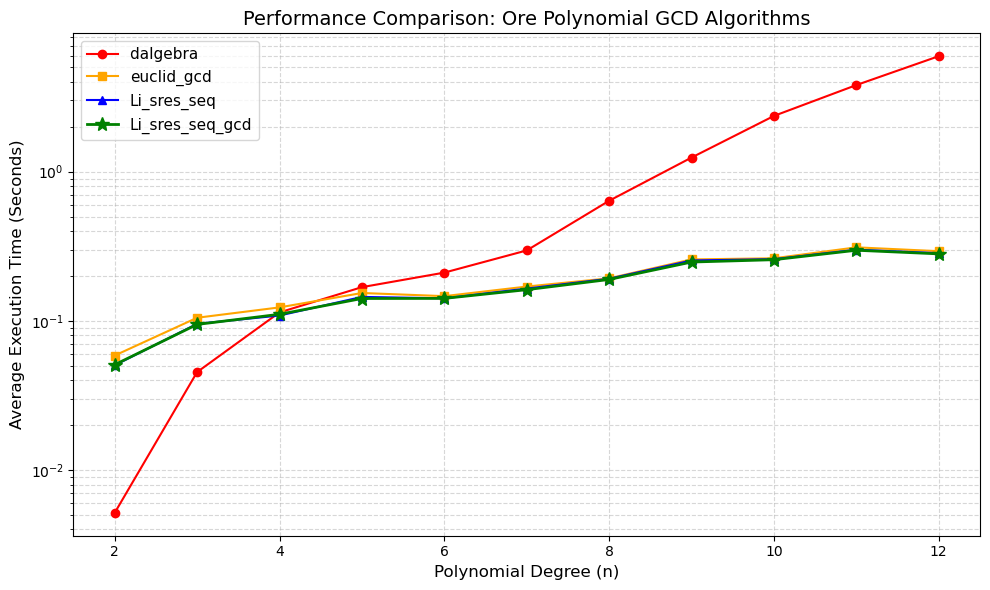

In [18]:
import time
import random
import matplotlib.pyplot as plt

# --- TEST RING ------
R.<t> = QQ[]
s = R.Hom(R)([-t])
td = R.derivation_module(twist=s)(1)
tR = DRing(R, td, types=["skew"])
t = tR.gens()[0]
O.<y> = DPolynomialRing(tR)
gen = O.gens()[0] # Assuming single skew.

# --- CONFIGURATION ---
max_degree = 12       # The maximum degree n to test up to
iterations = 5        # How many random pairs to average per degree
# -------------------

degrees = list(range(2, max_degree + 1))
times_dalgebra = []
times_euclid = []
times_li_seq = []
times_li_gcd = []

print(f"Starting benchmark up to degree {max_degree}...")

for n in degrees:
    t_dal, t_euc, t_li_s, t_li_g = 0, 0, 0, 0
    
    for _ in range(iterations):
        # Generate dense random polynomials of degree n and n-1
        p = sum([R.random_element(0, 5) * gen[i] for i in range(n + 1)])
        q = sum([R.random_element(0, 5) * gen[i] for i in range(n)])
        
        # 1. dalgebra 
        start = time.perf_counter()
        seq_dal = O.sylvester_subresultant_sequence(p, q)
        # Extract the lowest degree non-zero element (the GCD)
        gcd_dal = next(s for s in seq_dal if not s.is_zero())
        t_dal += time.perf_counter() - start
        
        # 2. Naive Euclid
        start = time.perf_counter()
        gcd_euc = gcd_euclid(p, q, s) #
        t_euc += time.perf_counter() - start
        
        # 3. Li Subresultant Sequence 
        start = time.perf_counter()
        seq_li = Li_sres_seq(p, q, s)
        # Extract the lowest index 
        gcd_li_seq = seq_li[min(seq_li.keys())]
        t_li_s += time.perf_counter() - start
        
        # 4. Li Subresultant GCD 
        start = time.perf_counter()
        gcd_li_fast = Li_sres_seq_gcd(p, q, s)
        t_li_g += time.perf_counter() - start

    # Average the times and store
    times_dalgebra.append(t_dal / iterations)
    times_euclid.append(t_euc / iterations)
    times_li_seq.append(t_li_s / iterations)
    times_li_gcd.append(t_li_g / iterations)
    
    print(f"Degree {n} completed.")

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.plot(degrees, times_dalgebra, marker='o', color='red', label='dalgebra ')
plt.plot(degrees, times_euclid, marker='s', color='orange', label='euclid_gcd')
plt.plot(degrees, times_li_seq, marker='^', color='blue', label='Li_sres_seq')
plt.plot(degrees, times_li_gcd, marker='*', color='green', linewidth=2, markersize=10, label='Li_sres_seq_gcd')

plt.title('Performance Comparison: Ore Polynomial GCD Algorithms', fontsize=14)
plt.xlabel('Polynomial Degree (n)', fontsize=12)
plt.ylabel('Average Execution Time (Seconds)', fontsize=12)
plt.yscale('log') # Log scale is highly recommended due to matrix explosion
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

In [19]:
print(times_dalgebra)
print(times_euclid)
print(times_li_seq)
print(times_li_gcd)

[0.005166037799790501, 0.04537825439474545, 0.11398832780541852, 0.1682986841944512, 0.2106364036037121, 0.2966156384034548, 0.6384639079973567, 1.243833152006846, 2.3650490269996225, 3.8077522172010503, 5.946122614404885]
[0.058586667402414604, 0.10495717959129251, 0.12314715180546046, 0.15379785440745763, 0.14649094679043628, 0.16987467140424997, 0.19286763839190826, 0.2582583688024897, 0.2627332813979592, 0.3111483108019456, 0.29317079920438116]
[0.050401848601177336, 0.09555003940477036, 0.10861624080571346, 0.14479912779061124, 0.14167451639077627, 0.16463917680084705, 0.1916308029962238, 0.2539918954076711, 0.25922745220013893, 0.30004417460295374, 0.2842662420065608]
[0.050852442800533026, 0.09467778260004707, 0.11070909120026044, 0.14126783140236512, 0.14148056120611727, 0.16185000700061208, 0.1895370857906528, 0.24795721399714238, 0.25710670139524155, 0.2974560615955852, 0.2812939573894255]
